In [3]:
# ============================================
# CELL 1: Import Required Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [4]:
# ============================================
# CELL 2: Load Dataset
# ============================================

# Load dataset from uploaded file
df = pd.read_csv('/content/tips.csv')  # Update path if needed

# Keep only the required columns
columns_required = ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']
df = df[columns_required]

# Display first few rows
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
# ============================================
# CELL 3: Basic Dataset Overview
# ============================================

print("Dataset Shape:", df.shape)
print("\nData Types:\n")
print(df.dtypes)

print("\nMissing Values:\n")
print(df.isnull().sum())

Dataset Shape: (244, 7)

Data Types:

total_bill    float64
tip           float64
sex            object
smoker         object
day            object
time           object
size            int64
dtype: object

Missing Values:

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


Task 2. Descriptive Analysis

In [6]:
# ============================================
# CELL 4: Descriptive Statistics (Numerical)
# ============================================

# Summary statistics for numerical columns
df[['total_bill', 'tip', 'size']].describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [7]:
# ============================================
# CELL 5: Descriptive Statistics (Categorical)
# ============================================

categorical_cols = ['sex', 'smoker', 'day', 'time']

for col in categorical_cols:
    print(f"\nValue Counts for {col}:\n")
    print(df[col].value_counts())
    print("-" * 40)


Value Counts for sex:

sex
Male      157
Female     87
Name: count, dtype: int64
----------------------------------------

Value Counts for smoker:

smoker
No     151
Yes     93
Name: count, dtype: int64
----------------------------------------

Value Counts for day:

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64
----------------------------------------

Value Counts for time:

time
Dinner    176
Lunch      68
Name: count, dtype: int64
----------------------------------------


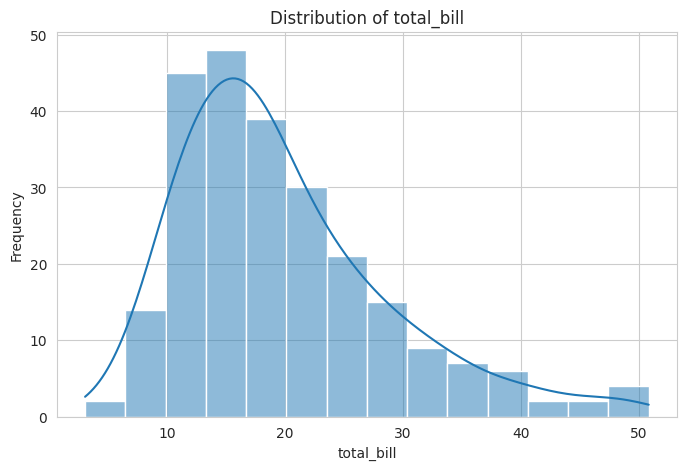

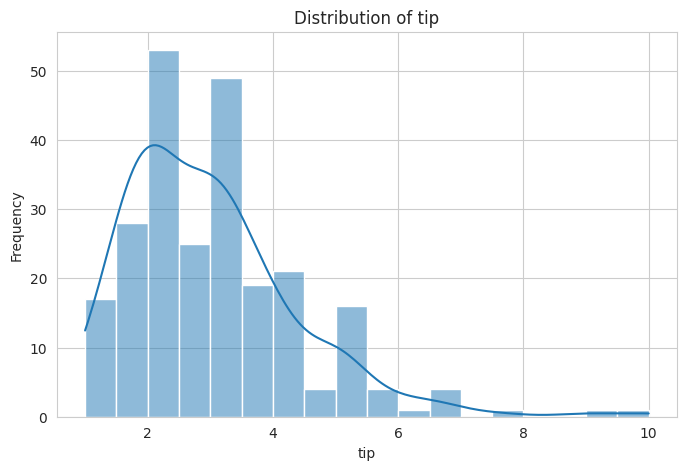

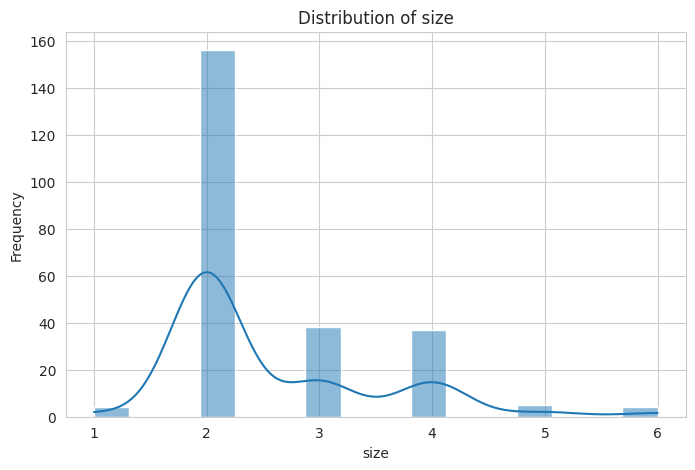

In [8]:
# ============================================
# CELL 6: Distribution Plots for Numerical Columns
# ============================================

numerical_cols = ['total_bill', 'tip', 'size']

for col in numerical_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

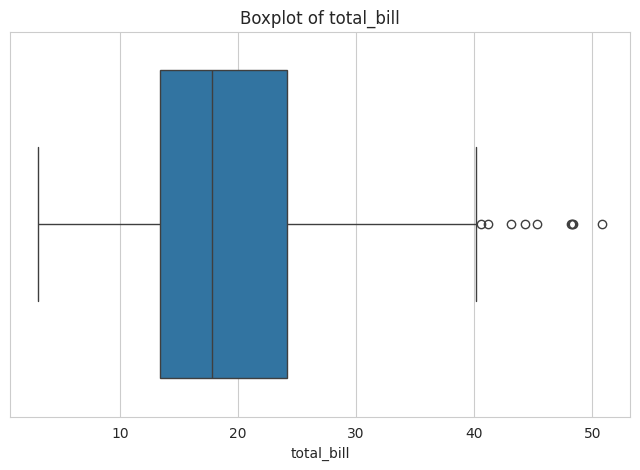

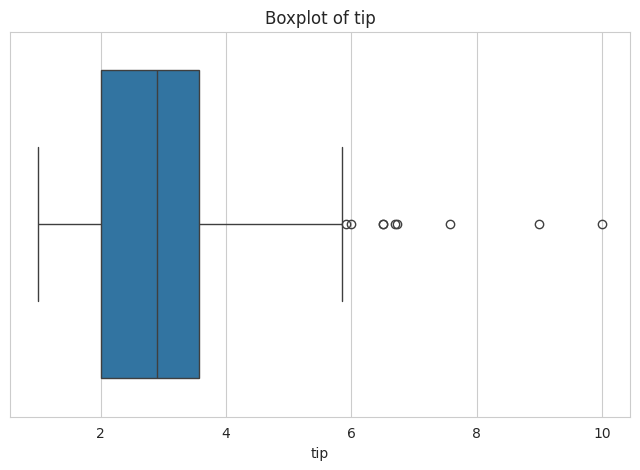

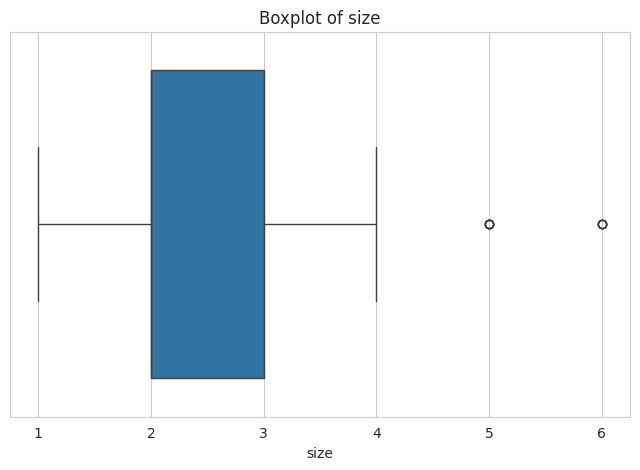

In [9]:
# ============================================
# CELL 7: Boxplots to Detect Spread & Outliers
# ============================================

for col in ['total_bill', 'tip', 'size']:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Task 3. Check for missing values,.

In [14]:
# ============================================
# Check for Missing Values in Important Columns
# ============================================

# Count missing values in each column
missing_values = df.isnull().sum()

# Calculate percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine both into a summary table
missing_summary = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage (%)': missing_percentage
})

# Display results
missing_summary

,Missing Count,Missing Percentage (%)
total_bill,0,0.0
tip,0,0.0
sex,0,0.0
smoker,0,0.0
day,0,0.0
time,0,0.0
size,0,0.0


Task 4. Outlier Analysis.

In [15]:
# ============================================
# Detect Outliers Using IQR Method
# ============================================

# Select numerical columns
numerical_cols = ['total_bill', 'tip', 'size']

# Create empty dictionary to store outlier information
outlier_summary = {}

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary[col] = {
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Number of Outliers': outliers.shape[0]
    }

# Convert dictionary to DataFrame for better display
outlier_summary_df = pd.DataFrame(outlier_summary).T
outlier_summary_df

,Lower Bound,Upper Bound,Number of Outliers
total_bill,-2.82250,40.29750,9.0
tip,-0.34375,5.90625,9.0
size,0.50000,4.50000,9.0


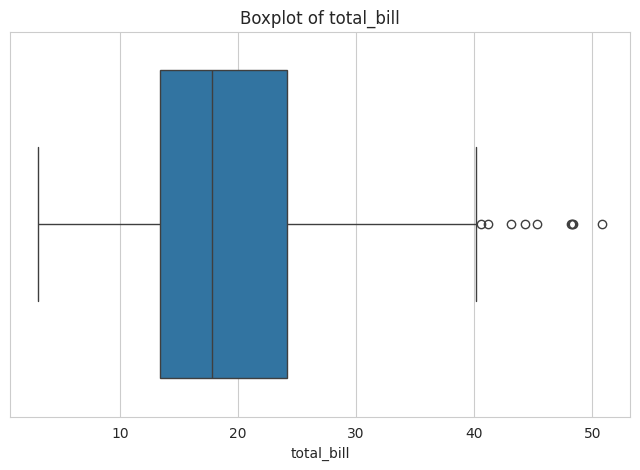

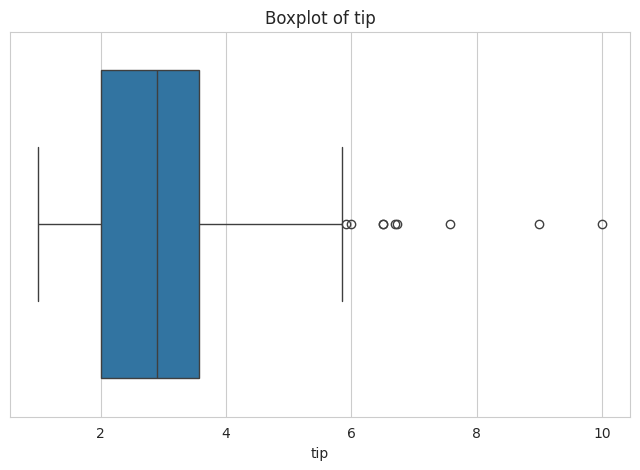

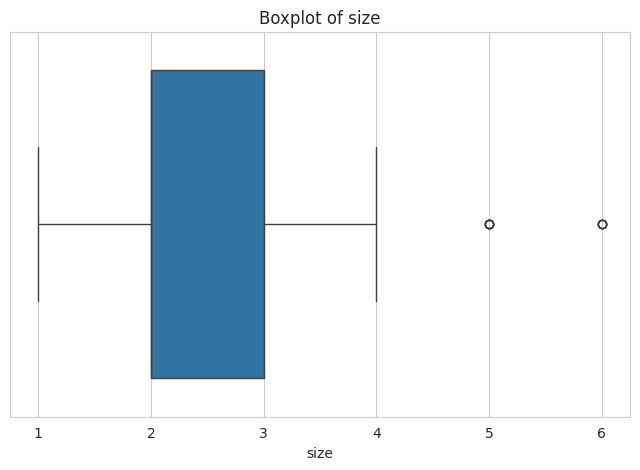

In [16]:
# ============================================
# Boxplots to Visualize Outliers
# ============================================

for col in numerical_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Task 5. Univariate Analysis

In [17]:
# ============================================
# Univariate Analysis - Numerical Summary
# ============================================

numerical_cols = ['total_bill', 'tip', 'size']

# Display descriptive statistics
df[numerical_cols].describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


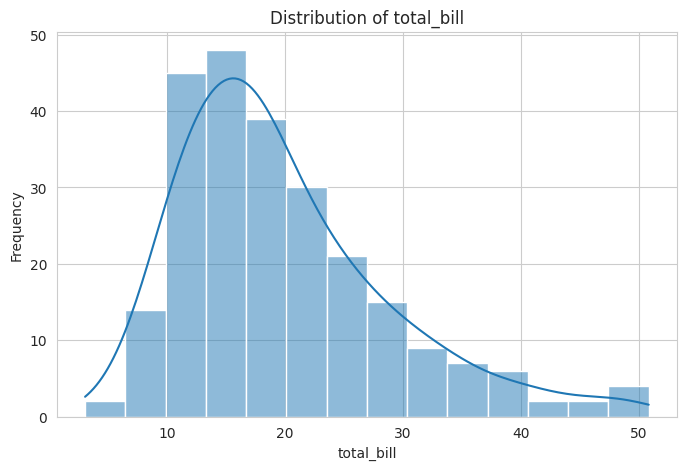

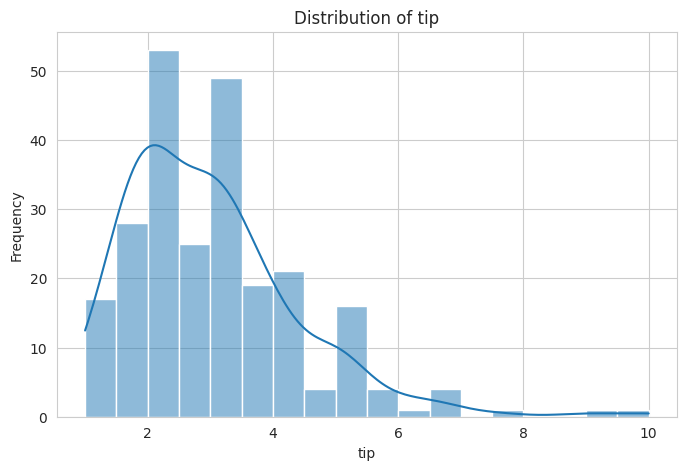

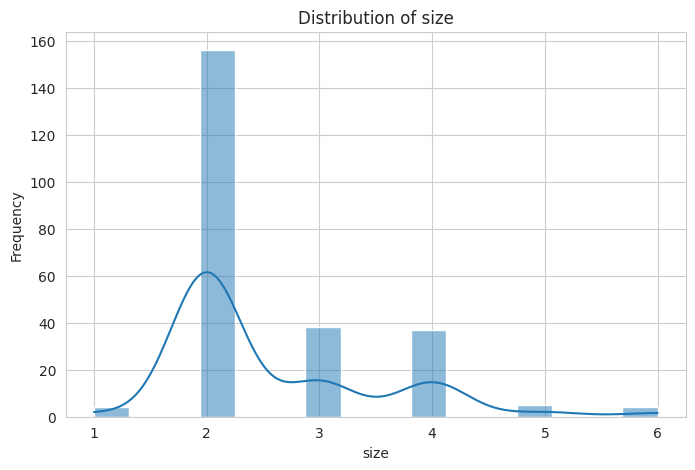

In [18]:
# ============================================
# Distribution Plots for Numerical Variables
# ============================================

for col in numerical_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

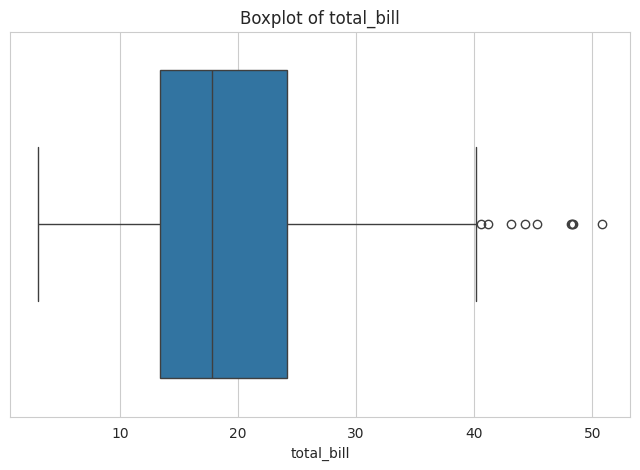

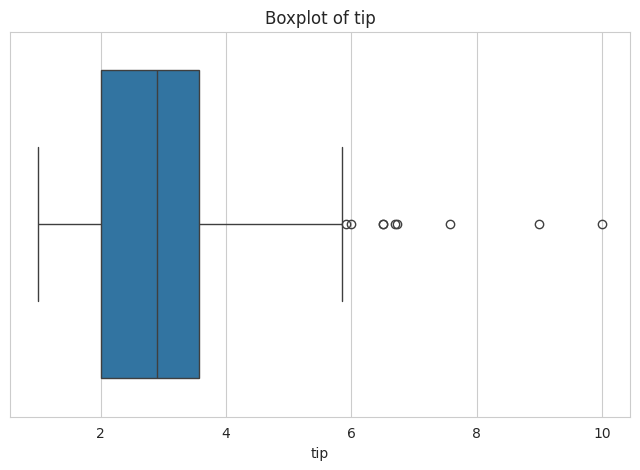

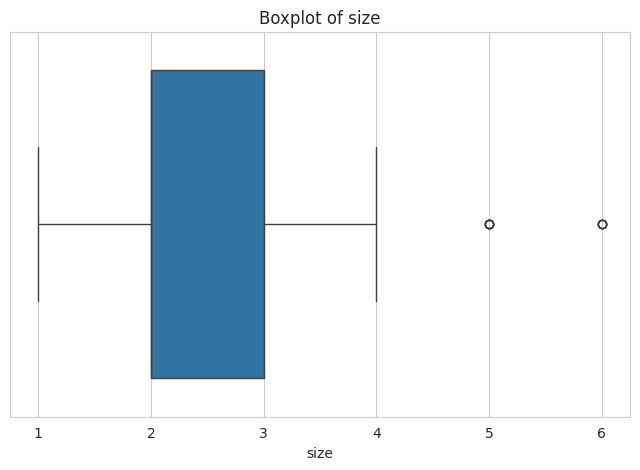

In [19]:
# ============================================
# Boxplots for Numerical Variables
# ============================================

for col in numerical_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [20]:
# ============================================
# Frequency Distribution for Categorical Variables
# ============================================

categorical_cols = ['sex', 'smoker', 'day', 'time']

for col in categorical_cols:
    print(f"\nValue Counts for {col}:\n")
    print(df[col].value_counts())
    print("-" * 40)


Value Counts for sex:

sex
Male      157
Female     87
Name: count, dtype: int64
----------------------------------------

Value Counts for smoker:

smoker
No     151
Yes     93
Name: count, dtype: int64
----------------------------------------

Value Counts for day:

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64
----------------------------------------

Value Counts for time:

time
Dinner    176
Lunch      68
Name: count, dtype: int64
----------------------------------------


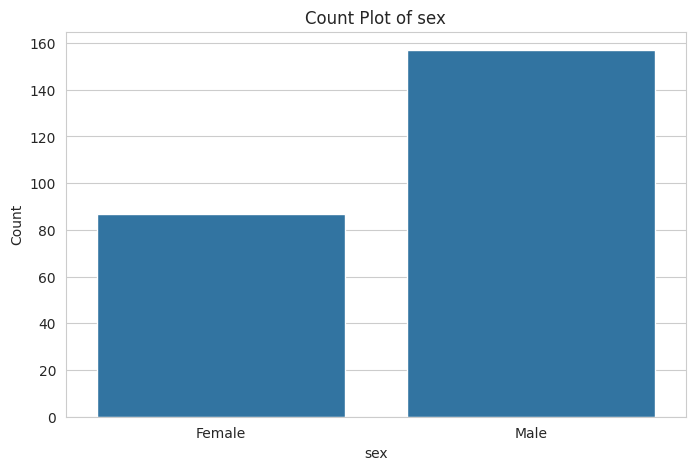

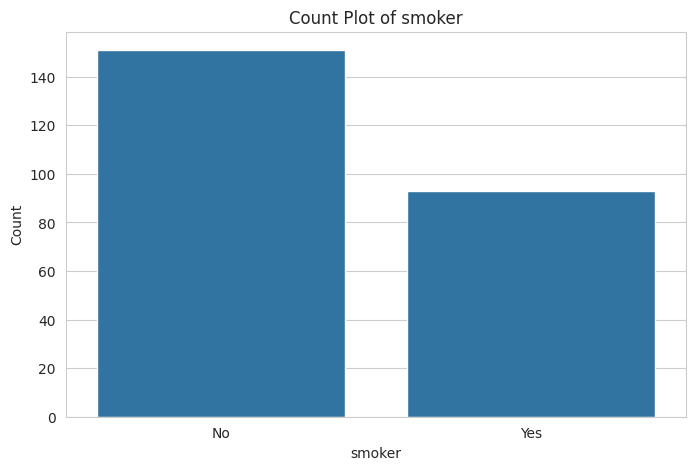

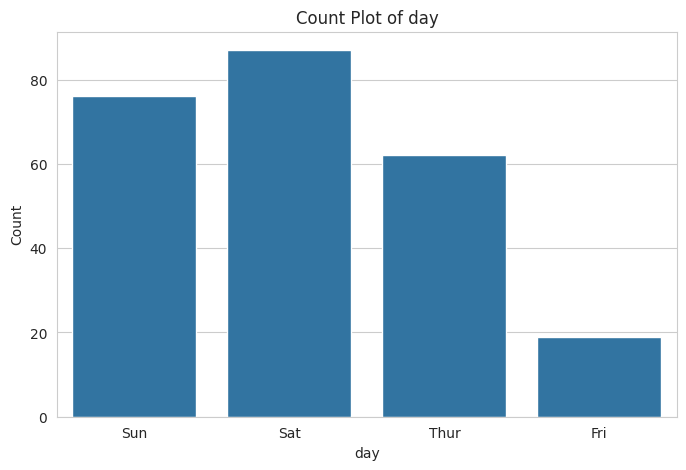

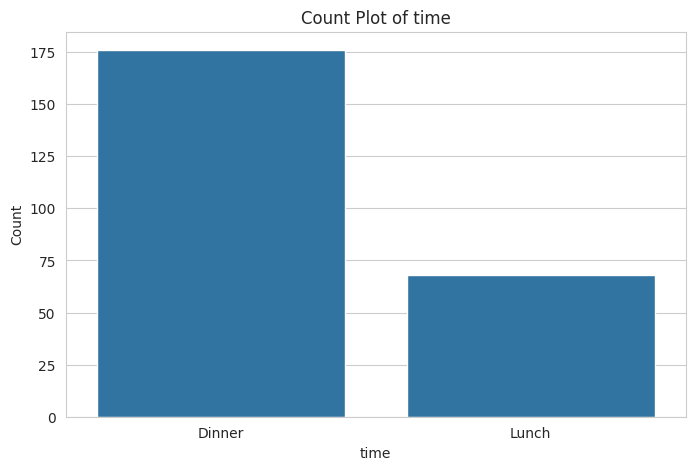

In [21]:
# ============================================
# Bar Plots for Categorical Variables
# ============================================

for col in categorical_cols:
    plt.figure()
    sns.countplot(x=df[col])
    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

Task 6. Bivariate Analysis of each column with tip

Correlation between total_bill and tip:

            total_bill       tip
total_bill    1.000000  0.675734
tip           0.675734  1.000000


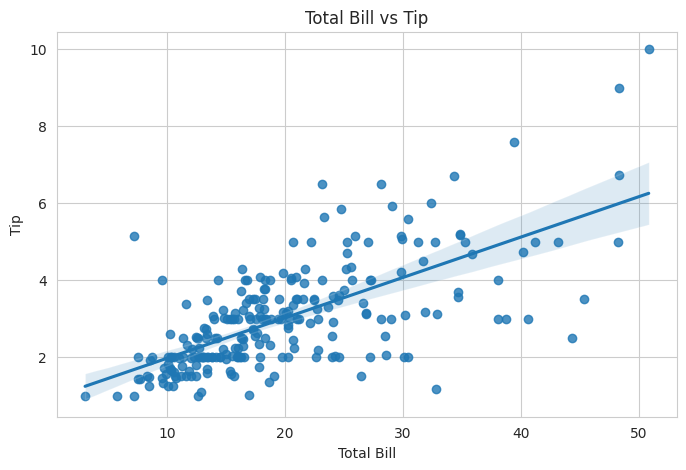

In [22]:
# ============================================
# total_bill vs tip
# ============================================

# Correlation
correlation = df[['total_bill', 'tip']].corr()
print("Correlation between total_bill and tip:\n")
print(correlation)

# Scatter plot with regression line
plt.figure()
sns.regplot(x='total_bill', y='tip', data=df)
plt.title('Total Bill vs Tip')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.show()

Correlation between size and tip:

          size       tip
size  1.000000  0.489299
tip   0.489299  1.000000


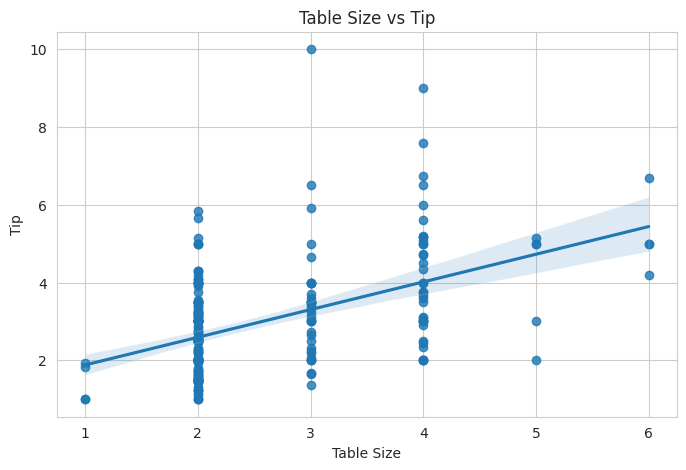

In [23]:
# ============================================
# size vs tip
# ============================================

# Correlation
correlation = df[['size', 'tip']].corr()
print("Correlation between size and tip:\n")
print(correlation)

# Scatter plot with regression line
plt.figure()
sns.regplot(x='size', y='tip', data=df)
plt.title('Table Size vs Tip')
plt.xlabel('Table Size')
plt.ylabel('Tip')
plt.show()

Average Tip by Sex:

        count      mean       std  min  25%   50%   75%   max
sex                                                          
Female   87.0  2.833448  1.159495  1.0  2.0  2.75  3.50   6.5
Male    157.0  3.089618  1.489102  1.0  2.0  3.00  3.76  10.0


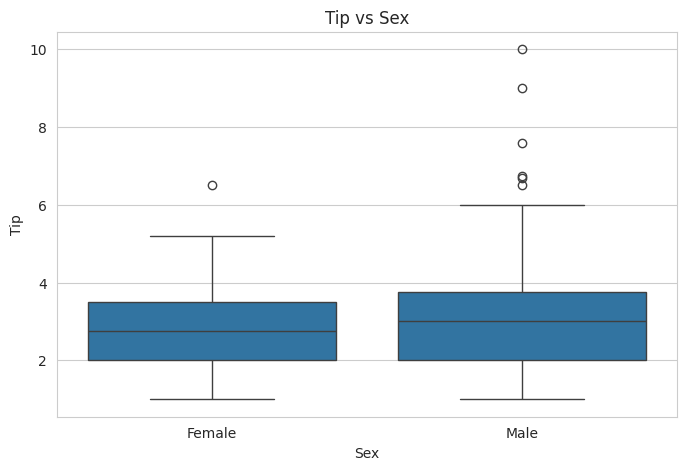

In [24]:
# ============================================
# sex vs tip
# ============================================

# Group statistics
print("Average Tip by Sex:\n")
print(df.groupby('sex')['tip'].describe())

# Boxplot
plt.figure()
sns.boxplot(x='sex', y='tip', data=df)
plt.title('Tip vs Sex')
plt.xlabel('Sex')
plt.ylabel('Tip')
plt.show()

Average Tip by Smoker:

        count      mean       std  min  25%   50%    75%   max
smoker                                                        
No      151.0  2.991854  1.377190  1.0  2.0  2.74  3.505   9.0
Yes      93.0  3.008710  1.401468  1.0  2.0  3.00  3.680  10.0


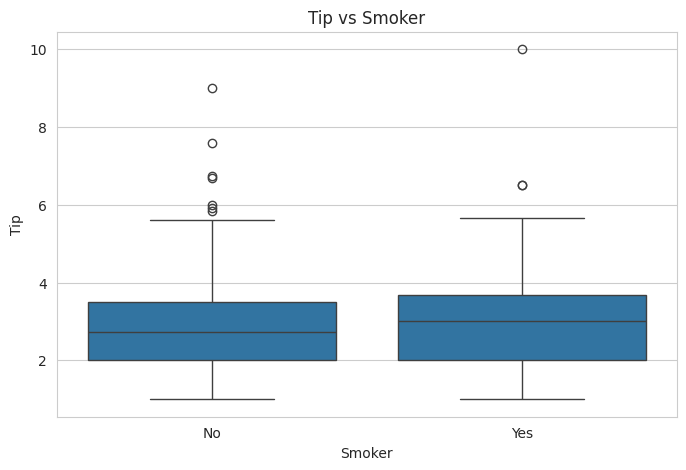

In [25]:
# ============================================
# smoker vs tip
# ============================================

# Group statistics
print("Average Tip by Smoker:\n")
print(df.groupby('smoker')['tip'].describe())

# Boxplot
plt.figure()
sns.boxplot(x='smoker', y='tip', data=df)
plt.title('Tip vs Smoker')
plt.xlabel('Smoker')
plt.ylabel('Tip')
plt.show()

Average Tip by Day:

      count      mean       std   min     25%    50%     75%    max
day                                                                
Fri    19.0  2.734737  1.019577  1.00  1.9600  3.000  3.3650   4.73
Sat    87.0  2.993103  1.631014  1.00  2.0000  2.750  3.3700  10.00
Sun    76.0  3.255132  1.234880  1.01  2.0375  3.150  4.0000   6.50
Thur   62.0  2.771452  1.240223  1.25  2.0000  2.305  3.3625   6.70


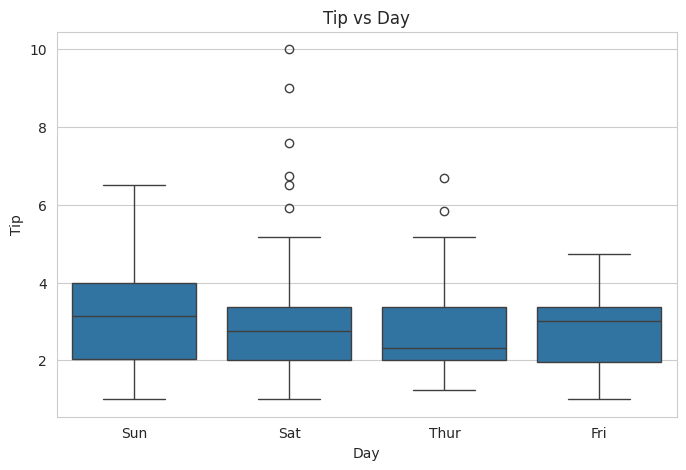

In [26]:
# ============================================
# day vs tip
# ============================================

# Group statistics
print("Average Tip by Day:\n")
print(df.groupby('day')['tip'].describe())

# Boxplot
plt.figure()
sns.boxplot(x='day', y='tip', data=df)
plt.title('Tip vs Day')
plt.xlabel('Day')
plt.ylabel('Tip')
plt.show()

Average Tip by Time:

        count      mean       std   min  25%   50%     75%   max
time                                                            
Dinner  176.0  3.102670  1.436243  1.00  2.0  3.00  3.6875  10.0
Lunch    68.0  2.728088  1.205345  1.25  2.0  2.25  3.2875   6.7


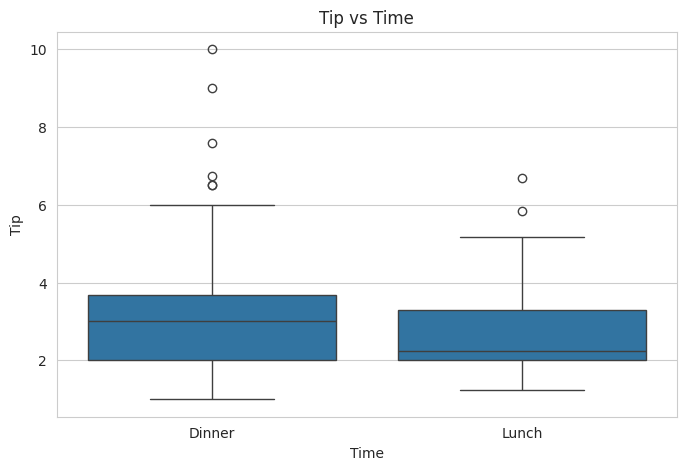

In [27]:
# ============================================
# time vs tip
# ============================================

# Group statistics
print("Average Tip by Time:\n")
print(df.groupby('time')['tip'].describe())

# Boxplot
plt.figure()
sns.boxplot(x='time', y='tip', data=df)
plt.title('Tip vs Time')
plt.xlabel('Time')
plt.ylabel('Tip')
plt.show()